# Module 2: Epidemic Modeling Template

## Team Members:
*(Fill in)*

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

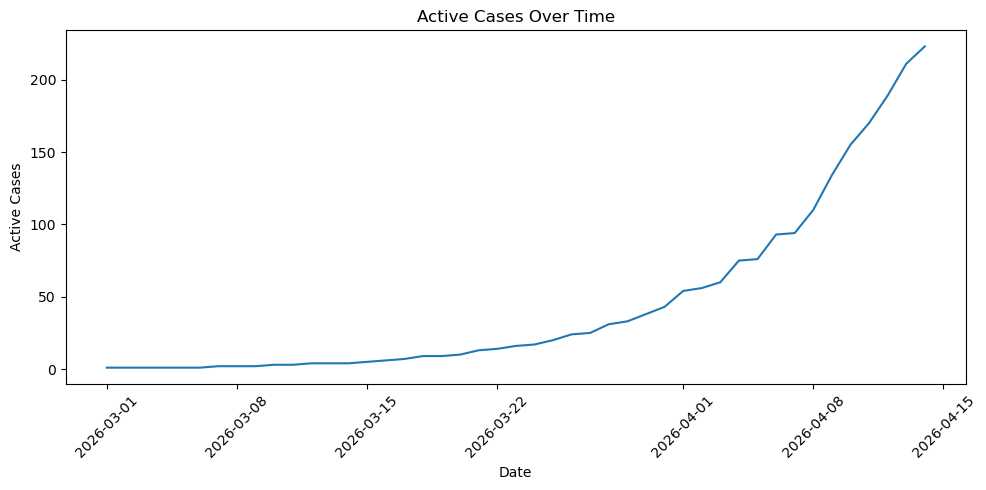

lambda = 0.1300 per day
doubling time = 5.3 days
R0 estimate = 1.91 (assuming 7 day infectious period)


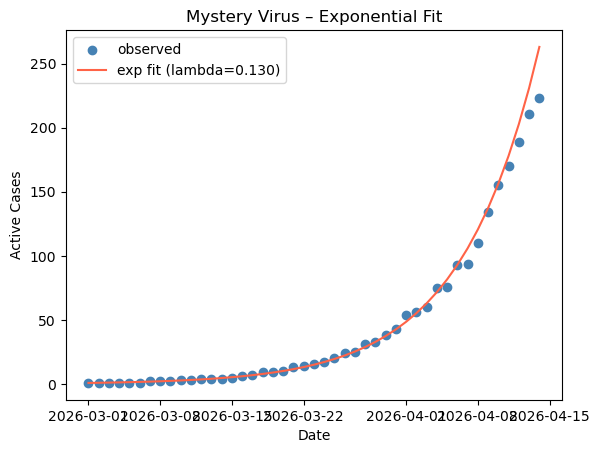

In [1]:
#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


#%%
# Load the data
#data = pd.read_csv(r'C:\Users\Jmarc\Desktop\Comp BME\module-2-jackmarchesi\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE_1.csv', parse_dates=['date'], header=0, index_col=None)
data = pd.read_csv(r'C:\Users\yancy\OneDrive\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE_1.csv', parse_dates=['date'], header=0, index_col=None)
data.columns = ['day', 'date', 'active_cases'] # Load the data from the specified CSV file, parsing the 'date' column as datetime objects. The header is set to 0 to indicate that the first row contains column names, and index_col is set to None to use the default integer index. After loading, we rename the columns to 'day', 'date', and 'active_cases' for easier reference in the analysis.

#%%
# Make a plot of the active cases over time

plt.figure(figsize=(10, 5)) #creating a plot of the active cases over time
plt.plot(data['date'], data['active_cases'])
plt.xlabel('Date')
plt.ylabel('Active Cases')
plt.title('Active Cases Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

growth = data[(data['day'] >= 7) & (data['day'] <= 40)] # growth is used to select the data from day 7 to day 40, which is the period of exponential growth
coefficients = np.polyfit(growth['day'], np.log(growth['active_cases']), 1) # np.polyfit is used to fit a line to the log of the active cases, which gives us the growth rate (lambda) as the slope of the line
lambd = coefficients[0] # the growth rate (lambda) is the first coefficient returned by np.polyfit, which is the slope of the line fitted to the log of the active cases
print(f'lambda = {lambd:.4f} per day') # print the growth rate (lambda) in per day units
print(f'doubling time = {np.log(2)/lambd:.1f} days') # the doubling time is calculated as the natural log of 2 divided by the growth rate (lambda), which gives us the time it takes for the number of active cases to double

# we assumed infectious period of 7 days to get R0 (given 1/7 was the number given in the slides for gamma, the recovery rate)
gamma = 1/7
R0 = (lambd + gamma) / gamma # R0 = (lambda + gamma) / gamma, where lambda is the growth rate and gamma is the recovery rate. This formula comes from the SIR model, where R0 represents the average number of secondary infections produced by a single infected individual in a completely susceptible population.
print(f'R0 estimate = {R0:.2f} (assuming 7 day infectious period)') #print the estimated R0 value, rounded to 2 decimal places


t_fit = np.arange(1, 46) # t_fit is an array of time points from day 1 to day 45, which we will use to plot the exponential fit of the active cases over time. This range is chosen to cover the period of exponential growth and a few days beyond it for visualization purposes.
I_fit = np.exp(coefficients[1] + lambd * t_fit) # I_fit is the exponential fit of the active cases over time, calculated using the coefficients from the linear fit to the log of the active cases. The formula used is I(t) = exp(intercept + lambda * t), where intercept is the second coefficient returned by np.polyfit (the y-intercept of the line fitted to the log of the active cases) and lambda is the growth rate. This gives us the predicted number of active cases at each time point in t_fit based on the exponential growth model.
dates_fit = data['date'].min() + pd.to_timedelta(t_fit - 1, unit='D') # dates_fit is an array of dates corresponding to the time points in t_fit.  The time delta is calculated as (t_fit - 1) days, which means that the first time point (t=1) corresponds to the minimum date, and subsequent time points correspond to subsequent days. This allows us to plot the exponential fit against the actual dates of the observed active cases.

plt.scatter(data['date'], data['active_cases'], color='steelblue', label='observed') # create a scatter plot of the observed active cases over time, with the dates on the x-axis and the number of active cases on the y-axis. The points are colored steelblue and labeled as 'observed' for the legend.
plt.plot(dates_fit, I_fit, color='tomato', label=f'exp fit (lambda={lambd:.3f})')
plt.xlabel('Date')
plt.ylabel('Active Cases')
plt.title('Mystery Virus – Exponential Fit')
plt.legend()
plt.savefig('active_cases_with_exponential_fit.png')
plt.show()


In [ ]:
#%%
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
#%%
# Load the data
data = pd.read_csv('../Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
#%%
# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data. 
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.

# Approximate R0 using this fit

# Add the fit as a line on top of your scatterplot.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*